In [1]:
# Imports here
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import torch
from torch import nn, optim
from torch.optim import lr_scheduler
from torch.autograd import Variable
import torchvision
import torch.utils.data as data
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights
import time
import json
import copy
import seaborn as sns
import numpy as np
from PIL import Image
from collections import OrderedDict
import matplotlib.pyplot as plt

In [2]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
def unnormalize(inp):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    return inp
data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomRotation(45),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            normalize
         ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            normalize
         ]),
        'test': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            normalize
         ])
    }


In [3]:
image_datasets = {
    "train" : torchvision.datasets.Flowers102("data", split="train", transform=data_transforms["train"], download=True),
    "val" : torchvision.datasets.Flowers102("data", split="val", transform=data_transforms["val"], download=True),
    "test" : torchvision.datasets.Flowers102("data", split="test", transform=data_transforms["val"], download=True)
}
# TODO: Using the image datasets and the trainforms, define the dataloaders
# defining data loaders to load data using image_datasets and transforms, here we also specify batch size for the mini batch
dataloaders = {
        x: data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=2)
        for x in list(image_datasets.keys())
    }
dataset_sizes = {
        x: len(dataloaders[x].dataset) 
        for x in list(image_datasets.keys())
    }
class_names = [
            "pink primrose",
            "hard-leaved pocket orchid",
            "canterbury bells",
            "sweet pea",
            "english marigold",
            "tiger lily",
            "moon orchid",
            "bird of paradise",
            "monkshood",
            "globe thistle",
            "snapdragon",
            "colts foot",
            "king protea",
            "spear thistle",
            "yellow iris",
            "globe-flower",
            "purple coneflower",
            "peruvian lily",
            "balloon flower",
            "giant white arum lily",
            "fire lily",
            "pincushion flower",
            "fritillary",
            "red ginger",
            "grape hyacinth",
            "corn poppy",
            "prince of wales feathers",
            "stemless gentian",
            "artichoke",
            "sweet william",
            "carnation",
            "garden phlox",
            "love in the mist",
            "mexican aster",
            "alpine sea holly",
            "ruby-lipped cattleya",
            "cape flower",
            "great masterwort",
            "siam tulip",
            "lenten rose",
            "barbeton daisy",
            "daffodil",
            "sword lily",
            "poinsettia",
            "bolero deep blue",
            "wallflower",
            "marigold",
            "buttercup",
            "oxeye daisy",
            "common dandelion",
            "petunia",
            "wild pansy",
            "primula",
            "sunflower",
            "pelargonium",
            "bishop of llandaff",
            "gaura",
            "geranium",
            "orange dahlia",
            "pink-yellow dahlia?",
            "cautleya spicata",
            "japanese anemone",
            "black-eyed susan",
            "silverbush",
            "californian poppy",
            "osteospermum",
            "spring crocus",
            "bearded iris",
            "windflower",
            "tree poppy",
            "gazania",
            "azalea",
            "water lily",
            "rose",
            "thorn apple",
            "morning glory",
            "passion flower",
            "lotus",
            "toad lily",
            "anthurium",
            "frangipani",
            "clematis",
            "hibiscus",
            "columbine",
            "desert-rose",
            "tree mallow",
            "magnolia",
            "cyclamen ",
            "watercress",
            "canna lily",
            "hippeastrum ",
            "bee balm",
            "ball moss",
            "foxglove",
            "bougainvillea",
            "camellia",
            "mallow",
            "mexican petunia",
            "bromelia",
            "blanket flower",
            "trumpet creeper",
            "blackberry lily"
        ]

In [4]:
dataset_sizes

{'train': 1020, 'val': 1020, 'test': 6149}

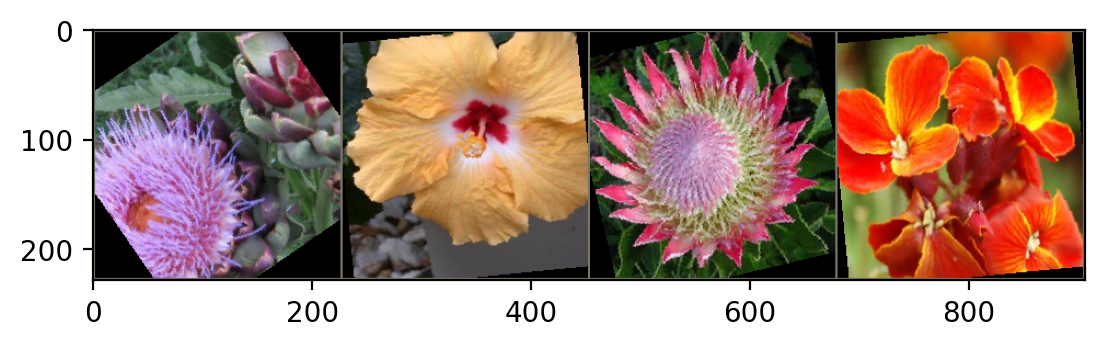

In [5]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = unnormalize(inp)
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=None)

In [6]:
model_ft = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1) # loading a pre-trained(trained on image net) resnet18 model from torchvision models
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 102) # changing the last layer for this dataset by setting last layer neurons to 102 as this dataset has 102 categories

In [7]:
use_gpu = torch.cuda.is_available() # if gpu is available then use it
if use_gpu:
    model_ft = model_ft.cuda()
criterion = nn.CrossEntropyLoss() # defining loss function
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.0001, momentum=0.9) # defining optimizer with learning rate set to 0.0001

In [8]:
def train_model(model, criterion, optimizer, num_epochs=10, device="cuda"):
    since = time.time()

    best_model_wts = model.state_dict()
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                #scheduler.step()
                model.train(True)  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for data in dataloaders[phase]:
                # get the inputs
                inputs, labels = data
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                outputs = model(inputs)
                
                preds = torch.argmax(outputs, 1)
                loss = criterion(outputs, labels)

                # backward + optimize only if in training phase
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

                # statistics
                running_loss += loss.item()
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = model.state_dict()
                # saving a checkpoint to use for next time to save time used in training from scratch
                state = {'model':model.state_dict(),'optim':optimizer.state_dict()}
                torch.save(state,'drive/flowers classification/point_resnet_best.pth')

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [9]:
def visualize_model(model, num_images=8):
    images_so_far = 0
    fig = plt.figure()
    

    for i, data in enumerate(dataloaders['val']):
        inputs, labels = data
        #print(labels)
        if use_gpu:
            inputs, labels = Variable(inputs.cuda()), Variable(labels.cuda())
        else:
            inputs, labels = Variable(inputs), Variable(labels)
        #print(labels)
        #_, lab = torch.max(labels.data, 1)
        outputs = model(inputs)
        #print(outputs)
        preds = torch.argmax(outputs.data, 1)
        #print(preds)

        for j in range(inputs.size()[0]):
            images_so_far += 1
            ax = plt.subplot(num_images//2, 2, images_so_far)
            ax.axis('off')
            ax.set_title('class: {} predicted: {}'.format(class_names[labels.data[j]], class_names[preds[j]]))
            imshow(inputs.cpu().data[j])

            if images_so_far == num_images:
                return

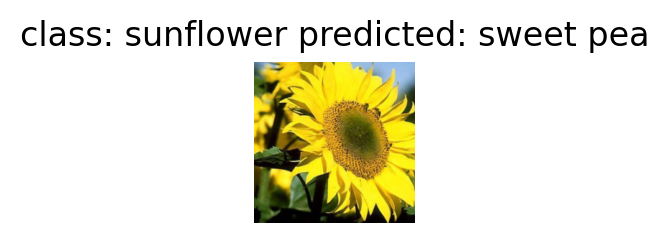

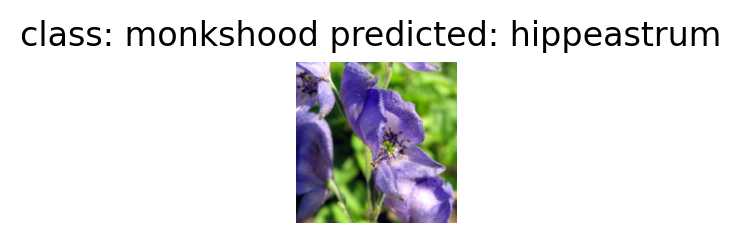

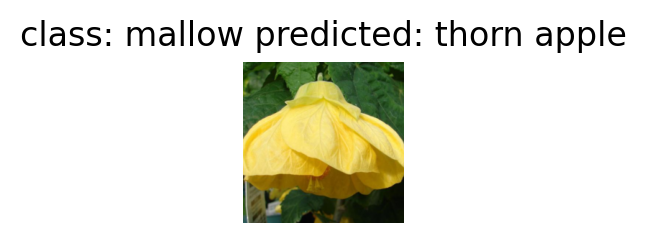

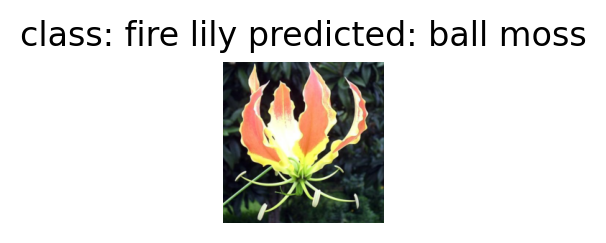

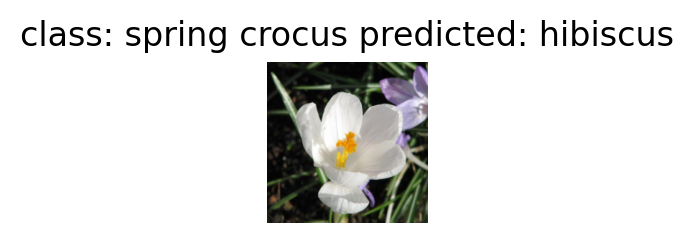

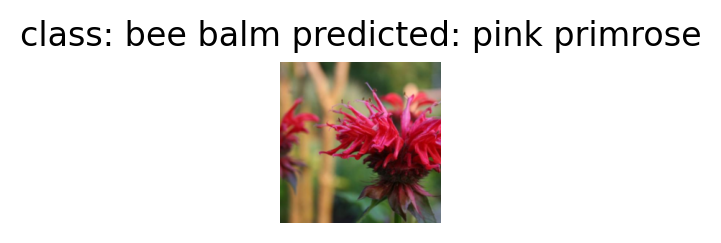

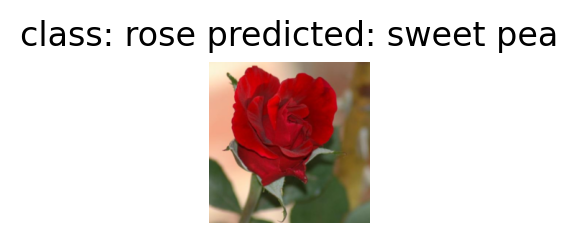

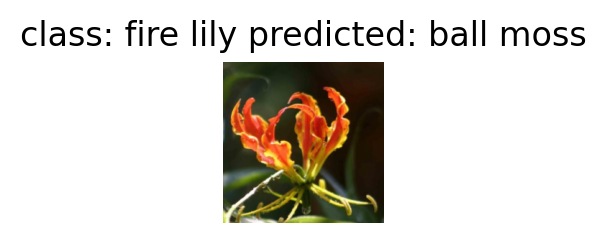

In [10]:
visualize_model(model_ft)

In [11]:
model_ft = train_model(model_ft, criterion, optimizer_ft,num_epochs=50)

Epoch 0/49
----------
train Loss: 1.1729 Acc: 0.0118
val Loss: 1.1422 Acc: 0.0275

Epoch 1/49
----------
train Loss: 1.1305 Acc: 0.0363
val Loss: 1.0845 Acc: 0.0784

Epoch 2/49
----------
train Loss: 1.0942 Acc: 0.0618
val Loss: 1.0302 Acc: 0.1343

Epoch 3/49
----------
train Loss: 1.0616 Acc: 0.1069
val Loss: 0.9670 Acc: 0.2265

Epoch 4/49
----------
train Loss: 1.0229 Acc: 0.1578
val Loss: 0.9056 Acc: 0.2863

Epoch 5/49
----------
train Loss: 0.9869 Acc: 0.2304
val Loss: 0.8457 Acc: 0.3304

Epoch 6/49
----------
train Loss: 0.9389 Acc: 0.2725
val Loss: 0.7709 Acc: 0.4078

Epoch 7/49
----------
train Loss: 0.9049 Acc: 0.3265
val Loss: 0.7170 Acc: 0.4471

Epoch 8/49
----------
train Loss: 0.8648 Acc: 0.3529
val Loss: 0.6533 Acc: 0.4902

Epoch 9/49
----------
train Loss: 0.8353 Acc: 0.3853
val Loss: 0.6087 Acc: 0.5225

Epoch 10/49
----------
train Loss: 0.8029 Acc: 0.4147
val Loss: 0.5624 Acc: 0.5461

Epoch 11/49
----------
train Loss: 0.7644 Acc: 0.4353
val Loss: 0.5185 Acc: 0.6010

Ep

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f83b780da50>>
Traceback (most recent call last):
  File "/home/chenningcong/Desktop/Deeplearning/deep/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 